# BERTweet Stance Classifier - Real vs GPT-4o-mini

Fine-tunes `BERTweet` on two training conditions, validates on real P-Stance val, evaluates on held-out real P-Stance test. Compares whether training on GPT-4o-mini synthetic tweets shifts classifier predictions on real tweets vs the real-data baseline.

**Conditions:**
1. **Real-only** - P-Stance train (baseline)
2. **GPT-4o-mini** - 7,200 synthetic tweets (closed API, current practitioner default for synthetic-data generation)

**Why GPT-4o-mini specifically:** chosen from the 7-generator audit (`03_SyntheticAudit.ipynb`) as the practitioner-default generator with the best form-factor parity to real P-Stance (172 vs 170 char, 1.67 vs 1.9 hashtags, mean cosine 0.668). This minimizes style confounds so the bias-transfer signal is attributable to content, not surface form.

**Bias transfer = per-target prediction shift between the two classifiers on the same real test set.**

**Hardware:** Colab A100 (or any GPU with >=10 GB VRAM). RoBERTa-base is 125M params - bf16/fp16 fits comfortably.

**Runtime:** ~5 min real-only + ~3 min GPT-4o-mini = **~10 min total at 1 seed**. Three-seed paper run: ~30 min.

**Project layout (Drive):** `MyDrive/PoliticalBiasProject/`
```
data/
  PStance/                  <- real data (you upload)
  synthetic_data/           <- gpt-4o-mini synthetic CSV (you upload)
models/roberta/             <- fine-tuned checkpoints
results/                    <- metrics CSV
figures/                    <- training curve plots
```

## 0. Colab setup — install + mount + create folders

In [1]:
!pip install -q transformers==4.45.0 accelerate==0.34.0 datasets==3.0.1 evaluate==0.4.3 scikit-learn pandas matplotlib

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/PoliticalBiasProject'
for sub in ['data/PStance', 'data/synthetic_data', 'models/roberta', 'results', 'figures']:
    os.makedirs(f'{PROJECT_DIR}/{sub}', exist_ok=True)
os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())
print('Subfolders :', sorted(os.listdir(PROJECT_DIR)))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 130.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
Mounted at /content/drive
Working dir: /content/drive/MyDrive/PoliticalBiasProject
Subfolder

## 1. Imports + config

In [2]:
import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
)

# ============ Classifier choice ============
# Swap MODEL_NAME + CLASSIFIER_TAG to rerun the same pipeline with a different classifier.
# Tested options:
#   ('FacebookAI/roberta-base',          'roberta')        # 125M, ~5 min/condition
#   ('vinai/bertweet-base',              'bertweet')       # 134M, tweet-pretrained, ~5 min/condition
#   ('microsoft/deberta-v3-base',        'deberta-v3')     # 184M, ~7 min/condition
MODEL_NAME      = 'vinai/bertweet-base'
CLASSIFIER_TAG  = 'bertweet'

# ============ Paths ============
PROJECT_DIR   = Path('/content/drive/MyDrive/PoliticalBiasProject')
DATA_DIR      = PROJECT_DIR / 'data' / 'PStance'
SYN_DIR       = PROJECT_DIR / 'data' / 'synthetic_data'

# Per-classifier roots — switching CLASSIFIER_TAG keeps outputs separate
MODELS_DIR    = PROJECT_DIR / 'models'  / CLASSIFIER_TAG
RESULTS_DIR   = PROJECT_DIR / 'results' / CLASSIFIER_TAG
FIG_DIR       = PROJECT_DIR / 'figures' / CLASSIFIER_TAG
for d in (MODELS_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEEDS         = [42, 123, 7]
PATIENCE      = 2
BATCH_SIZE    = 32
WARMUP_RATIO  = 0.1
MAX_LENGTH    = 128

# Per-condition hyperparameters
CONDITION_HP = {
    'real':         {'lr': 2e-5, 'weight_decay': 0.01, 'max_epochs': 5},
    'gpt-4o-mini':  {'lr': 1e-5, 'weight_decay': 0.10, 'max_epochs': 3},
    'mistral-7b':   {'lr': 1e-5, 'weight_decay': 0.10, 'max_epochs': 3},
    'qwen-2.5-7b':  {'lr': 1e-5, 'weight_decay': 0.10, 'max_epochs': 3},
    'llama-3.1-8b': {'lr': 1e-5, 'weight_decay': 0.10, 'max_epochs': 3},
    'mixed':        {'lr': 2e-5, 'weight_decay': 0.05, 'max_epochs': 4},
}

CONDITIONS    = [
    'real',
    'gpt-4o-mini',
    'mixed',
    # 'mistral-7b',
    # 'qwen-2.5-7b',
    # 'llama-3.1-8b',
]

# ============ RUN_TAG: distinguishes runs that use different condition combos ============
RUN_TAG = '+'.join(CONDITIONS)

RUN_FIG_DIR     = FIG_DIR     / RUN_TAG
RUN_RESULTS_DIR = RESULTS_DIR / RUN_TAG
RUN_HIST_DIR    = RESULTS_DIR / RUN_TAG / 'history'
for d in (RUN_FIG_DIR, RUN_RESULTS_DIR, RUN_HIST_DIR):
    d.mkdir(parents=True, exist_ok=True)

TARGETS       = ['Donald Trump', 'Joe Biden', 'Bernie Sanders']
LABEL2ID      = {'AGAINST': 0, 'FAVOR': 1}
ID2LABEL      = {v: k for k, v in LABEL2ID.items()}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device         : {device}')
if device == 'cuda':
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
print(f'\nClassifier     : {MODEL_NAME}  (tag: {CLASSIFIER_TAG})')
print(f'Conditions     : {CONDITIONS}')
print(f'Seeds          : {SEEDS}')
print(f'\nRUN_TAG        : {RUN_TAG}')
print(f'Models    -> {MODELS_DIR}/<condition>_seed<seed>/')
print(f'Figures   -> {RUN_FIG_DIR}')
print(f'Results   -> {RUN_RESULTS_DIR}')
print(f'History   -> {RUN_HIST_DIR}')

print(f'\nPer-condition hyperparams:')
for c in CONDITIONS:
    print(f'  {c:14s}  {CONDITION_HP[c]}')


Device         : cuda
GPU            : NVIDIA A100-SXM4-40GB

Classifier     : vinai/bertweet-base  (tag: bertweet)
Conditions     : ['real', 'gpt-4o-mini', 'mixed']
Seeds          : [42, 123, 7]

RUN_TAG        : real+gpt-4o-mini+mixed
Models    -> /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/<condition>_seed<seed>/
Figures   -> /content/drive/MyDrive/PoliticalBiasProject/figures/bertweet/real+gpt-4o-mini+mixed
Results   -> /content/drive/MyDrive/PoliticalBiasProject/results/bertweet/real+gpt-4o-mini+mixed
History   -> /content/drive/MyDrive/PoliticalBiasProject/results/bertweet/real+gpt-4o-mini+mixed/history

Per-condition hyperparams:
  real            {'lr': 2e-05, 'weight_decay': 0.01, 'max_epochs': 5}
  gpt-4o-mini     {'lr': 1e-05, 'weight_decay': 0.1, 'max_epochs': 3}
  mixed           {'lr': 2e-05, 'weight_decay': 0.05, 'max_epochs': 4}


## 2. Load data and build the four training conditions

Real P-Stance train: ~17K. GPT and Llama synthetic: 7,200 each. Mixed = 7,200 real (downsampled) + 7,200 GPT, shuffled. Validation and test always come from real P-Stance.

In [3]:
def load_real(split):
    parts = []
    for short in ['trump', 'biden', 'bernie']:
        df = pd.read_csv(DATA_DIR / f'raw_{split}_{short}.csv')
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

real_train = load_real('train')
real_val   = load_real('val')
real_test  = load_real('test')
print(f'Real train/val/test: {len(real_train):,} / {len(real_val):,} / {len(real_test):,}')

# Synthetic - only what is currently active in CONDITIONS
syn_gpt = pd.read_csv(next(SYN_DIR.glob('gpt-4o-mini-2024-07-18_synthetic_1200per_cell_*.csv')))[['Tweet', 'Target', 'Stance']]
print(f'GPT-4o-mini synth   : {len(syn_gpt):,}')

# Mixed: 50% real (downsampled to GPT size) + 50% GPT, shuffled
real_sample = real_train.sample(n=len(syn_gpt), random_state=42)[['Tweet', 'Target', 'Stance']]
mixed = pd.concat([real_sample, syn_gpt], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Mixed (50% real + 50% gpt-4o-mini): {len(mixed):,} (= {len(real_sample)} real + {len(syn_gpt)} synth)')

TRAIN_SETS = {
    'real':         real_train[['Tweet', 'Target', 'Stance']],
    'gpt-4o-mini':  syn_gpt,
    'mixed':        mixed,
}

for name, df in TRAIN_SETS.items():
    print(f'\n{name}: {len(df):,} rows | balance:')
    print(df.groupby(['Target', 'Stance']).size().unstack('Stance'))


Real train/val/test: 17,224 / 2,193 / 2,157
GPT-4o-mini synth   : 7,200
Mixed (50% real + 50% gpt-4o-mini): 14,400 (= 7200 real + 7200 synth)

real: 17,224 rows | balance:
Stance          AGAINST  FAVOR
Target                        
Bernie Sanders     2198   2858
Donald Trump       3425   2937
Joe Biden          3254   2552

gpt-4o-mini: 7,200 rows | balance:
Stance          AGAINST  FAVOR
Target                        
Bernie Sanders     1200   1200
Donald Trump       1200   1200
Joe Biden          1200   1200

mixed: 14,400 rows | balance:
Stance          AGAINST  FAVOR
Target                        
Bernie Sanders     2090   2421
Donald Trump       2651   2435
Joe Biden          2551   2252


## 3. Tokenization

Standard P-Stance setup: encode `Target [SEP] Tweet`. Single classifier across all targets ("merged" training); per-target metrics are computed at evaluation time.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset(df):
    df = df.copy()
    df['label'] = df['Stance'].map(LABEL2ID)
    df = df.dropna(subset=['Tweet', 'label'])
    df['text'] = df['Target'].astype(str) + ' </s> ' + df['Tweet'].astype(str)
    ds = Dataset.from_pandas(df[['text', 'label', 'Target']], preserve_index=False)
    ds = ds.map(lambda b: tokenizer(b['text'], truncation=True, max_length=MAX_LENGTH), batched=True)
    return ds

val_ds  = make_hf_dataset(real_val)
test_ds = make_hf_dataset(real_test)
print('Val tokens shape :', val_ds[0]['input_ids'][:10], '...')
print(f'Val / Test sizes : {len(val_ds):,} / {len(test_ds):,}')

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/2193 [00:00<?, ? examples/s]

Map:   0%|          | 0/2157 [00:00<?, ? examples/s]

Val tokens shape : [0, 2402, 394, 2, 1237, 1202, 10400, 1018, 5137, 158] ...
Val / Test sizes : 2,193 / 2,157


## 4. Training function — early stopping + linear-warmup-then-linear-decay LR schedule

`load_best_model_at_end=True` + `EarlyStoppingCallback(patience=2)` means training stops if val macro-F1 doesn't improve for 2 consecutive epochs, and the best-F1 checkpoint is restored. `lr_scheduler_type='linear'` gives 10% warmup + linear decay to 0.

In [5]:
def compute_metrics(eval_pred):
    preds  = eval_pred.predictions.argmax(-1)
    labels = eval_pred.label_ids
    return {
        'macro_f1':   f1_score(labels, preds, average='macro'),
        'favor_f1':   f1_score(labels, preds, pos_label=1),
        'against_f1': f1_score(labels, preds, pos_label=0),
    }

def train_one(condition, seed):
    set_seed(seed)
    train_ds = make_hf_dataset(TRAIN_SETS[condition])
    hp = CONDITION_HP[condition]

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID,
    )

    out_dir = MODELS_DIR / f'{condition}_seed{seed}'
    args = TrainingArguments(
        output_dir              = str(out_dir),
        num_train_epochs        = hp['max_epochs'],
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        learning_rate           = hp['lr'],
        warmup_ratio            = WARMUP_RATIO,
        weight_decay            = hp['weight_decay'],
        lr_scheduler_type       = 'linear',
        eval_strategy           = 'epoch',
        save_strategy           = 'epoch',
        load_best_model_at_end  = True,
        metric_for_best_model   = 'eval_macro_f1',
        greater_is_better       = True,
        save_total_limit        = 1,
        logging_steps           = 25,
        report_to               = 'none',
        seed                    = seed,
        fp16                    = (device == 'cuda'),
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        tokenizer       = tokenizer,
        data_collator   = DataCollatorWithPadding(tokenizer),
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )
    print(f'  hp: {hp}')
    trainer.train()
    return trainer


## 5. Train all conditions × seeds

In [6]:
all_trainers = {}
all_history  = {}

for condition in CONDITIONS:
    for seed in SEEDS:
        print(f'\n{"=" * 60}\n  Training: {condition}  (seed={seed})\n{"=" * 60}')
        trainer = train_one(condition, seed)
        all_trainers[(condition, seed)] = trainer
        all_history[(condition, seed)]  = list(trainer.state.log_history)

        # persist history immediately in case of crash later
        with open(RUN_HIST_DIR / f'history_{condition}_seed{seed}.json', 'w') as f:
            json.dump(all_history[(condition, seed)], f, indent=2, default=float)

print('\n✅ All training runs complete.')


  Training: real  (seed=42)


Map:   0%|          | 0/17224 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


  hp: {'lr': 2e-05, 'weight_decay': 0.01, 'max_epochs': 5}


...

Map:   0%|          | 0/14400 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


  hp: {'lr': 2e-05, 'weight_decay': 0.05, 'max_epochs': 4}


Epoch,Training Loss,Validation Loss,Macro F1,Favor F1,Against F1
1,0.246800,0.473157,0.785408,0.769458,0.801358
2,0.203800,0.513799,0.783902,0.770204,0.797599
3,0.159300,0.587917,0.795628,0.791434,0.799821
4,0.106600,0.719940,0.794682,0.789720,0.799644



✅ All training runs complete.


### Train the *mixed* condition only (skip already-trained conditions)

The original training loop trains every condition in `CONDITIONS`. Since real and gpt-4o-mini are already trained and saved on disk, this cell trains only `mixed` and adds it to `all_trainers`/`all_history`. Run this AFTER training the first two conditions, OR after running the resume-from-disk cell to load real/gpt-4o-mini back into memory.

In [7]:
# Train only the mixed condition; assumes real and gpt-4o-mini are already in all_trainers
NEW_CONDITIONS = ['mixed']

# If all_trainers/all_history don't exist yet (e.g. fresh kernel after resume), initialize them
try:
    all_trainers
    all_history
except NameError:
    all_trainers = {}
    all_history  = {}

for condition in NEW_CONDITIONS:
    for seed in SEEDS:
        if (condition, seed) in all_trainers:
            print(f'Skipping {condition} seed={seed} - already trained.')
            continue
        bar = '=' * 60
        print(f'\n{bar}\n  Training: {condition}  (seed={seed})\n{bar}')
        trainer = train_one(condition, seed)
        all_trainers[(condition, seed)] = trainer
        all_history[(condition, seed)]  = list(trainer.state.log_history)

        # persist history
        with open(RUN_HIST_DIR / f'history_{condition}_seed{seed}.json', 'w') as f:
            json.dump(all_history[(condition, seed)], f, indent=2, default=float)

print(f'\n[OK] Mixed training complete. all_trainers now contains {len(all_trainers)} (condition, seed) pairs.')


Skipping mixed seed=42 - already trained.
Skipping mixed seed=123 - already trained.
Skipping mixed seed=7 - already trained.

[OK] Mixed training complete. all_trainers now contains 9 (condition, seed) pairs.


## 6. Plot training curves

Three panels: training loss per step, validation macro-F1 per epoch, learning-rate schedule. One line per (condition, seed). Saved to `figures/training_curves.png`.

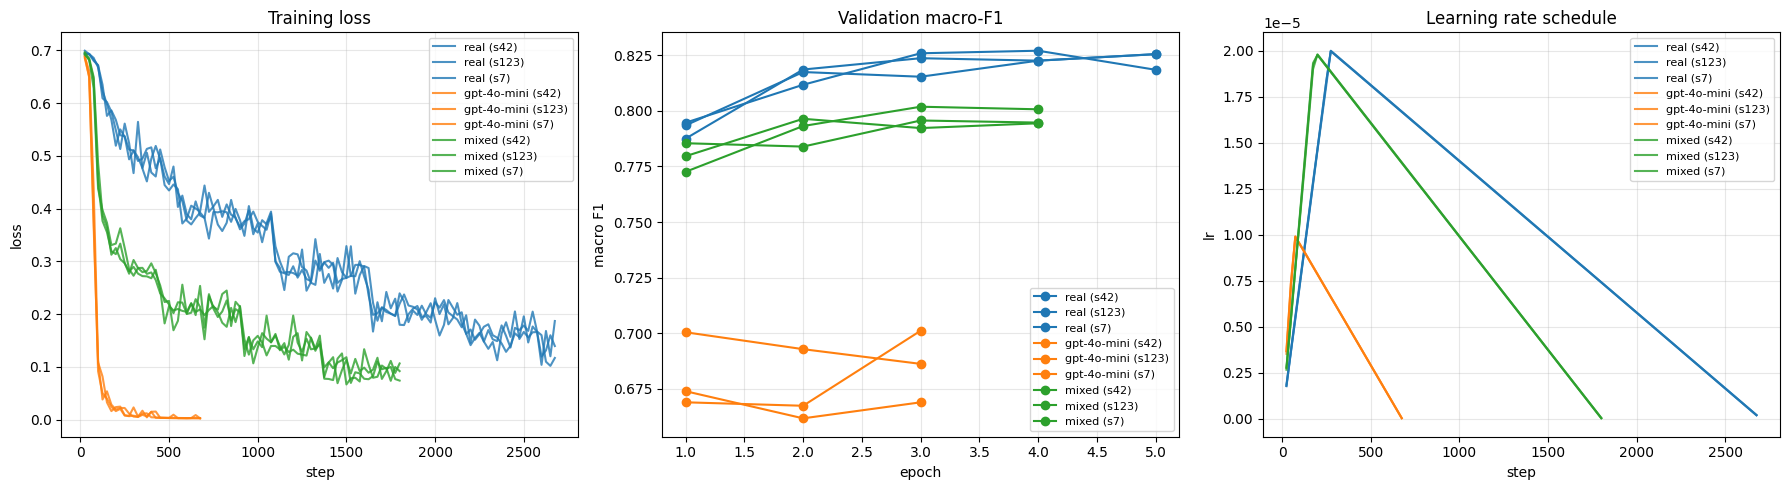

Saved -> /content/drive/MyDrive/PoliticalBiasProject/figures/bertweet/real+gpt-4o-mini+mixed/training_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color_for = {c: f'C{i}' for i, c in enumerate(CONDITIONS)}

for (cond, seed), hist in all_history.items():
    train_loss = [(h['step'], h['loss']) for h in hist if 'loss' in h and 'eval_loss' not in h]
    val_f1     = [(h['epoch'], h['eval_macro_f1']) for h in hist if 'eval_macro_f1' in h]
    lr_pts     = [(h['step'], h['learning_rate']) for h in hist if 'learning_rate' in h]

    label = f'{cond} (s{seed})'
    color = color_for[cond]

    if train_loss:
        axes[0].plot([s for s, _ in train_loss], [l for _, l in train_loss], color=color, alpha=0.8, label=label)
    if val_f1:
        axes[1].plot([e for e, _ in val_f1], [v for _, v in val_f1], color=color, marker='o', label=label)
    if lr_pts:
        axes[2].plot([s for s, _ in lr_pts], [l for _, l in lr_pts], color=color, alpha=0.8, label=label)

axes[0].set_title('Training loss');           axes[0].set_xlabel('step');  axes[0].set_ylabel('loss')
axes[1].set_title('Validation macro-F1');     axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro F1')
axes[2].set_title('Learning rate schedule');  axes[2].set_xlabel('step');  axes[2].set_ylabel('lr')

for ax in axes:
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_FIG_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved -> {RUN_FIG_DIR / 'training_curves.png'}")

## 7. Evaluate on real P-Stance test (held-out)

Per-target macro-F1 + overall. ALL conditions are evaluated on the same real test set — never on synthetic — so prediction differences are attributable to training data only.

In [9]:
results = []
predictions = {}

for (cond, seed), trainer in all_trainers.items():
    pred = trainer.predict(test_ds)
    preds  = pred.predictions.argmax(-1)
    probs  = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()
    labels = pred.label_ids

    test_df = real_test.copy().reset_index(drop=True)
    test_df['pred']   = preds
    test_df['p_favor'] = probs[:, 1]
    predictions[(cond, seed)] = test_df

    # Per-target F1
    for target in TARGETS:
        sub = test_df[test_df.Target == target]
        results.append({
            'condition': cond, 'seed': seed, 'target': target,
            'macro_f1':   f1_score(sub['Stance'].map(LABEL2ID), sub['pred'], average='macro'),
            'favor_f1':   f1_score(sub['Stance'].map(LABEL2ID), sub['pred'], pos_label=1),
            'against_f1': f1_score(sub['Stance'].map(LABEL2ID), sub['pred'], pos_label=0),
            'n':          len(sub),
        })
    # Overall
    results.append({
        'condition': cond, 'seed': seed, 'target': 'OVERALL',
        'macro_f1':   f1_score(labels, preds, average='macro'),
        'favor_f1':   f1_score(labels, preds, pos_label=1),
        'against_f1': f1_score(labels, preds, pos_label=0),
        'n':          len(test_df),
    })

results_df = pd.DataFrame(results)
results_df.to_csv(RUN_RESULTS_DIR / 'test_metrics.csv', index=False)

print('Macro-F1 per condition × target (averaged across seeds):')
pivot = results_df.pivot_table(index='condition', columns='target', values='macro_f1', aggfunc='mean').round(3)
pivot = pivot[['Donald Trump', 'Joe Biden', 'Bernie Sanders', 'OVERALL']]
print(pivot)

Macro-F1 per condition × target (averaged across seeds):
target       Donald Trump  Joe Biden  Bernie Sanders  OVERALL
condition                                                    
gpt-4o-mini         0.674      0.760           0.671    0.704
mixed               0.823      0.814           0.760    0.804
real                0.844      0.820           0.777    0.817


## 8. Bias-shift metrics (3-axis, per PROJECT_CONTEXT.md)

**(a) Class Distribution Shift:** for each (condition, target, class), compare the predicted class rate against the real-only baseline.

**(b) Directional Bias Score:**
$$\text{BiasScore} = (\Delta_{Biden,Favor} - \Delta_{Trump,Favor}) + (\Delta_{Trump,Against} - \Delta_{Biden,Against})$$
Positive = left-leaning shift; negative = right-leaning shift; near zero = no detectable bias transfer.

In [10]:
# Predicted FAVOR-rate per (condition, target), averaged across seeds
rows = []
for (cond, seed), df in predictions.items():
    for target in TARGETS:
        sub = df[df.Target == target]
        rows.append({
            'condition': cond, 'seed': seed, 'target': target,
            'favor_rate':   (sub['pred'] == 1).mean(),
            'against_rate': (sub['pred'] == 0).mean(),
        })
rates = pd.DataFrame(rows).groupby(['condition', 'target'])[['favor_rate', 'against_rate']].mean()
print('Predicted FAVOR / AGAINST rates per condition × target:')
print(rates.round(3))

# Class-distribution deltas vs the real baseline
real_baseline = rates.xs('real', level='condition')
deltas = rates.subtract(real_baseline, level='target')
deltas = deltas.drop('real', level='condition')
print('\nClass distribution shift  Δ(condition, target) = P_synth(yhat) - P_real(yhat):')
print(deltas.round(3))

# Directional bias score per condition
print('\nDirectional Bias Score (positive = left-leaning, negative = right-leaning):')
for cond in [c for c in CONDITIONS if c != 'real']:
    d = deltas.xs(cond, level='condition')
    score = (d.loc['Joe Biden', 'favor_rate'] - d.loc['Donald Trump', 'favor_rate']) \
          + (d.loc['Donald Trump', 'against_rate'] - d.loc['Joe Biden', 'against_rate'])
    print(f'  {cond:14s}  Bias = {score:+.3f}')

Predicted FAVOR / AGAINST rates per condition × target:
                            favor_rate  against_rate
condition   target                                  
gpt-4o-mini Bernie Sanders       0.403         0.597
            Donald Trump         0.329         0.671
            Joe Biden            0.359         0.641
mixed       Bernie Sanders       0.571         0.429
            Donald Trump         0.439         0.561
            Joe Biden            0.411         0.589
real        Bernie Sanders       0.551         0.449
            Donald Trump         0.447         0.553
            Joe Biden            0.444         0.556

Class distribution shift  Δ(condition, target) = P_synth(yhat) - P_real(yhat):
                            favor_rate  against_rate
condition   target                                  
gpt-4o-mini Bernie Sanders      -0.148         0.148
            Donald Trump        -0.119         0.119
            Joe Biden           -0.085         0.085
mixed       Bern

## 9. Summary plot — per-target F1 by condition

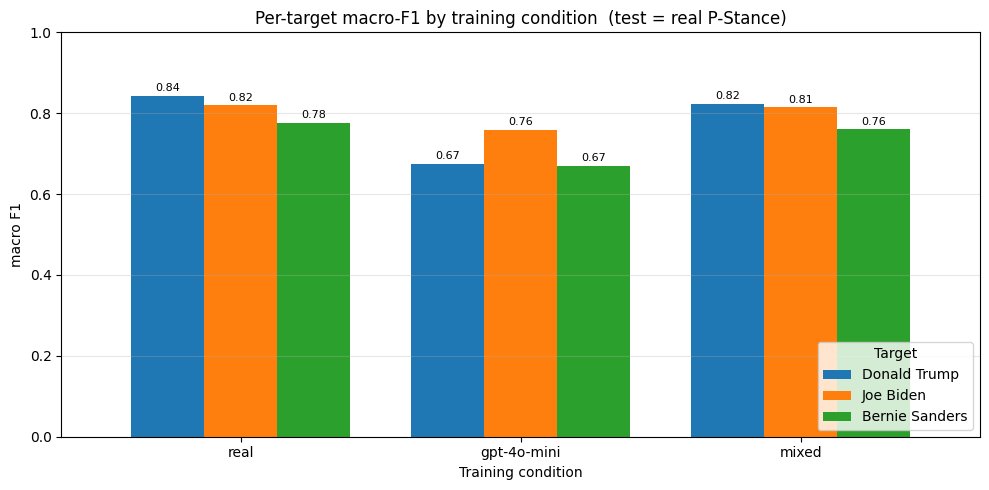

Saved -> /content/drive/MyDrive/PoliticalBiasProject/figures/bertweet/real+gpt-4o-mini+mixed/per_target_f1.png


In [11]:
agg = results_df[results_df.target != 'OVERALL'].groupby(['condition', 'target'])['macro_f1'].mean().unstack('target')
agg = agg.loc[CONDITIONS, TARGETS]   # consistent ordering

fig, ax = plt.subplots(figsize=(10, 5))
agg.plot(kind='bar', ax=ax, width=0.78)
ax.set_title('Per-target macro-F1 by training condition  (test = real P-Stance)')
ax.set_ylabel('macro F1')
ax.set_xlabel('Training condition')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.grid(alpha=0.3, axis='y')
ax.legend(title='Target', loc='lower right')

for cont in ax.containers:
    ax.bar_label(cont, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(RUN_FIG_DIR / 'per_target_f1.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved -> {RUN_FIG_DIR / 'per_target_f1.png'}")

## 10. Done — what's in `results/` and `figures/`

After this notebook completes, your `MyDrive/PoliticalBiasProject/` will contain:

- `models/roberta/<condition>_seed<seed>/` — best-F1 checkpoint per run
- `results/roberta_test_metrics.csv` — per-target macro-F1, FAVOR-F1, AGAINST-F1, per condition × seed
- `results/history_<condition>_seed<seed>.json` — full HF Trainer log (loss, lr, eval F1 per step)
- `figures/training_curves.png` — loss / val-F1 / LR over training
- `figures/per_target_f1.png` — per-target test F1 by condition

**Next:**
1. Sync `results/` and `figures/` back to your local repo for git
2. Re-run with `SEEDS = [42, 123, 7]` for the 3-seed paper version (~45 min on A100)
3. Build `05_Llama_FineTune.ipynb` for the Llama-3-8B-base + LoRA classifier (parallel pipeline)

## 11. Resume from disk + balanced-test robustness check

Two things this section adds:

**A. Resume support** — if your runtime disconnects after training, run cell B below to reload the best checkpoints from disk (saved by `Trainer` with `load_best_model_at_end=True` + `save_total_limit=1`). You can then re-run sections 7-9 without retraining.

**B. Balanced-test evaluation** — re-runs the bias-shift measurement on a class-balanced subset of the real test set (downsampled per-target so FAVOR == AGAINST count). This is a robustness check: if the +0.427 Bias Score holds on a balanced test subset, it can't be explained away as a test-set class-prior artifact.

(Note: the cleanest "isolate prior shift from content shift" experiment would require retraining a balanced-real condition. The balanced-test check below is the cheap proxy and a sanity check, not a full disentanglement.)

In [12]:
# Resume from disk — reloads best-F1 checkpoint per (condition, seed) into a Trainer
# Run this if you want to skip the training cell after a kernel disconnect.

from transformers import AutoModelForSequenceClassification, AutoTokenizer

def find_best_checkpoint(condition_dir):
    """Trainer with save_total_limit=1 leaves only the best checkpoint folder."""
    candidates = sorted([p for p in condition_dir.iterdir() if p.is_dir() and p.name.startswith("checkpoint-")])
    if not candidates:
        raise FileNotFoundError(f"No checkpoint dir under {condition_dir}")
    return candidates[-1]

loaded_trainers = {}
for condition in CONDITIONS:
    for seed in SEEDS:
        ckpt_dir = find_best_checkpoint(MODELS_DIR / f"{condition}_seed{seed}")
        print(f"Loading {condition} seed={seed}: {ckpt_dir}")
        model = AutoModelForSequenceClassification.from_pretrained(str(ckpt_dir))
        model.to(device).eval()

        # Reuse the existing Trainer scaffolding for predict()
        args = TrainingArguments(
            output_dir=str(ckpt_dir),
            per_device_eval_batch_size=BATCH_SIZE,
            report_to="none",
            do_train=False,
        )
        trainer = Trainer(
            model=model, args=args,
            tokenizer=tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer),
            compute_metrics=compute_metrics,
        )
        loaded_trainers[(condition, seed)] = trainer

print(f"Reloaded {len(loaded_trainers)} trainers.")
print("You can now substitute `loaded_trainers` for `all_trainers` in evaluation cells.")
all_trainers = loaded_trainers


Loading real seed=42: /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/real_seed42/checkpoint-2156


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Loading real seed=123: /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/real_seed123/checkpoint-2695


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Loading real seed=7: /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/real_seed7/checkpoint-2695


...

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Loading mixed seed=123: /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/mixed_seed123/checkpoint-1350


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Loading mixed seed=7: /content/drive/MyDrive/PoliticalBiasProject/models/bertweet/mixed_seed7/checkpoint-1350
Reloaded 9 trainers.
You can now substitute `loaded_trainers` for `all_trainers` in evaluation cells.


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


### Balanced-test predictions and Bias Score

Builds a per-target balanced subset of the real test set (FAVOR count == AGAINST count, sampled to the smaller class), then re-runs predictions and the Bias Score formula on it. Compare against the original (imbalanced) numbers.

In [13]:
# Build per-target balanced test subset
balanced_idx = []
for target in TARGETS:
    sub = real_test[real_test.Target == target]
    fav_idx = sub[sub.Stance == "FAVOR"].index.tolist()
    agn_idx = sub[sub.Stance == "AGAINST"].index.tolist()
    n = min(len(fav_idx), len(agn_idx))
    rng = np.random.default_rng(42)
    fav_keep = rng.choice(fav_idx, size=n, replace=False).tolist()
    agn_keep = rng.choice(agn_idx, size=n, replace=False).tolist()
    balanced_idx.extend(fav_keep + agn_keep)

real_test_balanced = real_test.loc[balanced_idx].reset_index(drop=True)
test_ds_balanced  = make_hf_dataset(real_test_balanced)

print("\nOriginal real_test:")
print(real_test.groupby(["Target", "Stance"]).size().unstack("Stance"))
print("\nBalanced real_test_balanced:")
print(real_test_balanced.groupby(["Target", "Stance"]).size().unstack("Stance"))

# Run predictions on the balanced subset
results_balanced = []
predictions_balanced = {}
for (cond, seed), trainer in all_trainers.items():
    pred = trainer.predict(test_ds_balanced)
    preds = pred.predictions.argmax(-1)
    rt_b = real_test_balanced.copy().reset_index(drop=True)
    rt_b["pred"] = preds
    predictions_balanced[(cond, seed)] = rt_b

    for target in TARGETS:
        sub = rt_b[rt_b.Target == target]
        results_balanced.append({
            "condition": cond, "seed": seed, "target": target,
            "macro_f1":   f1_score(sub["Stance"].map(LABEL2ID), sub["pred"], average="macro"),
            "favor_rate": (sub["pred"] == 1).mean(),
        })

balanced_df = pd.DataFrame(results_balanced)
print("\nBalanced-test macro-F1 per condition x target:")
print(balanced_df.pivot_table(index="condition", columns="target", values="macro_f1", aggfunc="mean").round(3))

# Recompute Bias Score on balanced test
rates_b = balanced_df.groupby(["condition", "target"])["favor_rate"].mean().unstack("target")
print("\nBalanced-test predicted FAVOR rate per condition x target:")
print(rates_b.round(3))

real_baseline_b = rates_b.loc["real"]
deltas_b = rates_b.subtract(real_baseline_b, axis=1).drop("real")
print("\nDelta(condition, target) on balanced test:")
print(deltas_b.round(3))

print("\nBalanced-test Directional Bias Score:")
for cond in [c for c in CONDITIONS if c != "real"]:
    d = deltas_b.loc[cond]
    against = 1 - rates_b.loc[cond]
    real_against = 1 - rates_b.loc["real"]
    against_delta = (against - real_against)
    score = (d["Joe Biden"] - d["Donald Trump"]) + (against_delta["Donald Trump"] - against_delta["Joe Biden"])
    print(f"  {cond:14s}  Bias = {score:+.3f}")

# Save balanced results
balanced_df.to_csv(RUN_RESULTS_DIR / 'test_metrics_BALANCED.csv', index=False)
print(f"\nSaved -> {RUN_RESULTS_DIR / 'test_metrics_BALANCED.csv'}")


Map:   0%|          | 0/1962 [00:00<?, ? examples/s]


Original real_test:
Stance          AGAINST  FAVOR
Target                        
Bernie Sanders      292    343
Donald Trump        425    352
Joe Biden           408    337

Balanced real_test_balanced:
Stance          AGAINST  FAVOR
Target                        
Bernie Sanders      292    292
Donald Trump        352    352
Joe Biden           337    337



Balanced-test macro-F1 per condition x target:
target       Bernie Sanders  Donald Trump  Joe Biden
condition                                           
gpt-4o-mini           0.666         0.666      0.751
mixed                 0.754         0.819      0.810
real                  0.773         0.838      0.818

Balanced-test predicted FAVOR rate per condition x target:
target       Bernie Sanders  Donald Trump  Joe Biden
condition                                           
gpt-4o-mini           0.378         0.347      0.386
mixed                 0.546         0.473      0.442
real                  0.526         0.485      0.475

Delta(condition, target) on balanced test:
target       Bernie Sanders  Donald Trump  Joe Biden
condition                                           
gpt-4o-mini          -0.147        -0.138     -0.089
mixed                 0.020        -0.012     -0.033

Balanced-test Directional Bias Score:
  gpt-4o-mini     Bias = +0.098
  mixed           Bias = -0.042

Sa